1.

Title:  Customer Churn and Win-Back Targeting  

Team: Sina Odejinmi  

Date: 11-10-2025

2.

Business problem:


Leadership wants:
1) A churn score for each active customer.
2) A budget-aware rule for whom to contact and how many to contact per 1,000 customers.

Task: Deliver an end-to-end pipeline that transforms raw data into actionable retention decisions.


3.

Leakage Policy
**Definition:** Leakage is any use of future information not available at decision time.

**Enforcement:**
- Score customers at the end of billing period.
- Use only information available before that moment.





4.

Data setup

In [ ]:
import pandas as pd


df = pd.read_csv("churn_train.csv")
print("Shape:", df.shape)
df.head()


Shape: (5634, 21)


,ID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,yrhdgfy_4741,Male,0,No,No,35,No,No phone service,DSL,No,...,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,49.20,1701.65,No
1,yrhdgfy_4154,Male,0,Yes,Yes,15,Yes,No,Fiber optic,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,75.10,1151.55,No
2,yrhdgfy_5863,Male,0,Yes,Yes,13,No,No phone service,DSL,Yes,...,No,Yes,No,No,Two year,No,Mailed check,40.55,590.35,No
3,yrhdgfy_4870,Female,0,Yes,No,26,Yes,No,DSL,No,...,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),73.50,1905.7,No
4,yrhdgfy_4813,Male,0,Yes,Yes,1,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,No,Electronic check,44.55,44.55,No


Find out if df has any missing values

In [ ]:
df.isnull().sum().sum()

np.int64(0)

 Preprocessing Setup

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Separate features and target
X = df.drop(columns=["ID", "Churn"])
y = df["Churn"].map({"Yes": 1, "No": 0})

# Identify column types
categorical_cols = X.select_dtypes(include="object").columns.tolist()
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Numeric preprocessing (no imputer needed)
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# Categorical preprocessing (no imputer needed)
categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])


5.

Model Training & Validation: Three models — Logistic Regression, Random Forest, Gradient Boosted Trees (5-fold cross-validation

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, brier_score_loss
import numpy as np
import pandas as pd

# Step 4. Define models
models = {
    "Logistic": LogisticRegression(max_iter=500, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced"
    ),
    "GBT": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )
}

# Step 5. Choose evaluation strategy (Option A: 5-fold Stratified CV)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Step 6. Wrap into pipelines and evaluate
results = []

for name, clf in models.items():
    aucs, briers = [], []
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),   # your preprocessing pipeline defined earlier
        ("classifier", clf)
    ])
    # train_idx → row indices for training set
       # val_idx → row indices for validation set
       # X_train → features for training fold
       # X_val → features for validation fold
       # y_train → churn labels for training fold
       # y_val → churn labels for validation fold
    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        pipeline.fit(X_train, y_train)
        preds = pipeline.predict_proba(X_val)[:, 1]

        aucs.append(roc_auc_score(y_val, preds))
        briers.append(brier_score_loss(y_val, preds))

    results.append({
        "Model": name,
        "Mean AUC": np.mean(aucs),
        "Mean Brier": np.mean(briers)
    })

# Display results
pd.DataFrame(results)


,Model,Mean AUC,Mean Brier
0,Logistic,0.845354,0.155696
1,RandomForest,0.822309,0.145284
2,GBT,0.848042,0.134473


The Gradient Boosting (GBT) model is the final model because it has the highest AUC and the lowest *Briers* score

6.
Model validation (AUC + Brier) and Platt-scaled calibration for best-performing model, saved as figures/calibration.png
Calibration Plot

Step 1. Wrap Gradient Boosting with Platt scaling and Reliability curve (calibration plot)



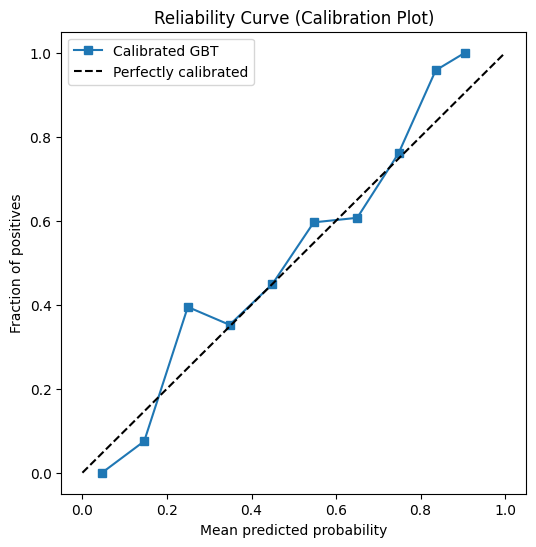

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import matplotlib.pyplot as plt

# --- Preprocessing setup (no imputers needed) ---
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

# --- Base model ---
gbt = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# --- Pipeline with preprocessing + model ---
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", gbt)
])

# --- Calibrate with Platt scaling ---
calibrated_clf = CalibratedClassifierCV(
    estimator=pipeline,   # pipeline ensures categorical features are encoded
    method="sigmoid",
    cv=3
)

# Fit on full dataset
calibrated_clf.fit(X, y)

# --- Reliability curve ---
probs = calibrated_clf.predict_proba(X)[:, 1]
fraction_of_positives, mean_predicted_value = calibration_curve(y, probs, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(mean_predicted_value, fraction_of_positives, "s-", label="Calibrated GBT")
plt.plot([0,1], [0,1], "k--", label="Perfectly calibrated")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Reliability Curve (Calibration Plot)")
plt.legend()
plt.show()


Ablation table

7.

One ablation table (AUC + Brier changes per feature group) for best-performing model

In [ ]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, brier_score_loss

# --- Define feature groups ---
groups = {
    "demographics": ["gender", "SeniorCitizen", "Partner", "Dependents"],
    "account": ["tenure", "Contract", "PaperlessBilling", "PaymentMethod"],
    "internet": ["InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport"],
    "streaming": ["StreamingTV", "StreamingMovies"],
    "phone": ["PhoneService", "MultipleLines"],
    "charges": ["MonthlyCharges", "TotalCharges"]
}

# --- Helper function to build pipeline (no calibration) ---
def build_pipeline(features):
    num_cols = [c for c in features if X[c].dtype in ["int64", "float64"]]
    cat_cols = [c for c in features if X[c].dtype == "object"]

    transformers = []
    if num_cols:
        transformers.append(("num", StandardScaler(), num_cols))
    if cat_cols:
        transformers.append(("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols))

    preprocessor = ColumnTransformer(transformers=transformers)

    gbt = GradientBoostingClassifier(
        n_estimators=100,   # fewer trees for speed
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", gbt)
    ])
    return pipeline

# --- Baseline model with all features ---
all_features = sum(groups.values(), [])
baseline_model = build_pipeline(all_features)
baseline_model.fit(X, y)
baseline_probs = baseline_model.predict_proba(X)[:, 1]
baseline_auc = roc_auc_score(y, baseline_probs)
baseline_brier2 = brier_score_loss(y, baseline_probs)

results = []
results.append(["All features", baseline_auc, baseline_brier2, 0.0, 0.0])

# --- Ablation: drop each group ---
for group_name, group_features in groups.items():
    reduced_features = [f for f in all_features if f not in group_features]
    model = build_pipeline(reduced_features)
    model.fit(X, y)
    probs = model.predict_proba(X)[:, 1]
    auc = roc_auc_score(y, probs)
    brier2 = brier_score_loss(y, probs)
    delta_auc = auc - baseline_auc
    delta_brier2 = brier2 - baseline_brier2
    results.append([f"Drop {group_name}", auc, brier2, delta_auc, delta_brier2])

# --- Assemble results into table ---
ablation_table = pd.DataFrame(results, columns=["Feature Set", "AUC", "Brier2", "ΔAUC", "ΔBrier2"])
print(ablation_table)


         Feature Set       AUC    Brier2      ΔAUC   ΔBrier2
0       All features  0.889684  0.120670  0.000000  0.000000
1  Drop demographics  0.889234  0.121037 -0.000450  0.000367
2       Drop account  0.844283  0.141631 -0.045401  0.020961
3      Drop internet  0.884529  0.123115 -0.005155  0.002445
4     Drop streaming  0.889437  0.120871 -0.000247  0.000201
5         Drop phone  0.889020  0.121341 -0.000665  0.000671
6       Drop charges  0.870864  0.124291 -0.018820  0.003621


Comments on Ablation results

Account features (tenure, contract, billing, payment method) are the most predictive. Dropping them hurts AUC and worsens calibration.

Charges are the second most important. Customers’ spending patterns matter a lot.

Internet services contribute modestly.

Demographics, streaming, and phone services barely move the needle. They add little incremental predictive power. They can be dropped from the final model.

Full OOF Predictions + Evaluation Code

Fast OOF Predictions with Final Model (Dropped Features)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, brier_score_loss

# --- Load training data ---
train = pd.read_csv("churn_train.csv")

# Map target labels to numeric: Yes → 1, No → 0
train["Churn"] = train["Churn"].map({"Yes": 1, "No": 0})

X = train.drop("Churn", axis=1)
y = train["Churn"]

# --- Final feature groups (drop demographics, streaming, phone) ---
final_features = [
    "tenure", "Contract", "PaperlessBilling", "PaymentMethod",   # account
    "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",  # internet
    "MonthlyCharges", "TotalCharges"  # charges
]

X = X[final_features]

# --- Preprocessing ---
num_cols = [c for c in final_features if X[c].dtype in ["int64", "float64"]]
cat_cols = [c for c in final_features if X[c].dtype == "object"]

transformers = []
if num_cols:
    transformers.append(("num", StandardScaler(), num_cols))
if cat_cols:
    transformers.append(("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols))

preprocessor = ColumnTransformer(transformers=transformers)

# --- Gradient Boosting (fast mode) ---
gbt = GradientBoostingClassifier(
    n_estimators=100,   # fewer trees for speed
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", gbt)
])

# --- Calibrated model ---
calibrated = CalibratedClassifierCV(estimator=pipeline, method="sigmoid", cv=3)  # 3 folds for speed

# --- Generate OOF predictions ---
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))

for train_idx, valid_idx in cv.split(X, y):
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    calibrated.fit(X_train, y_train)
    oof_preds[valid_idx] = calibrated.predict_proba(X_valid)[:, 1]

# --- Save OOF predictions ---
oof_df = pd.DataFrame({
    "id": train.index,   # or use customer ID if available
    "y_true": y,
    "y_pred": oof_preds
})
oof_df.to_csv("oof_predictions.csv", index=False)

# --- Evaluate ---
auc = roc_auc_score(y, oof_preds)
brier2 = brier_score_loss(y, oof_preds)

print("Saved oof_predictions.csv with shape:", oof_df.shape) # id: the row index, y_true: the actual churn label (0 = No, 1 = Yes), y_pred : the predicted churn probability from your OOF CV loop.y_pred → the predicted churn probability from your OOF CV loop.
print("OOF AUC:", auc)
print("OOF Brier2:", brier2)


Saved oof_predictions.csv with shape: (5634, 3)
OOF AUC: 0.8463213530484559
OOF Brier2: 0.1347698574260063


In [ ]:
print("Saved oof_predictions.csv with shape:", oof_df.shape)
print("OOF AUC:", format(auc, ".6f"))
print("OOF Brier2:", format(brier2, ".6f"))


Saved oof_predictions.csv with shape: (5634, 3)
OOF AUC: 0.846321
OOF Brier2: 0.134770


In [ ]:
import os

# Make sure the 'figures' directory exists
os.makedirs("figures", exist_ok=True)




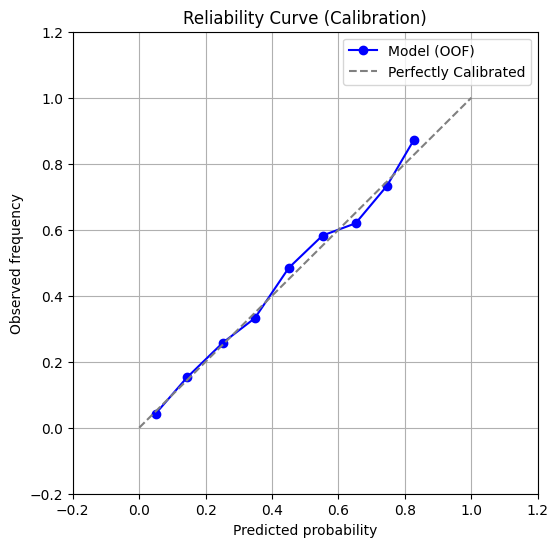

Saved reliability curve to figures/calibration.png


In [ ]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
import os

# --- Ensure figures folder exists ---
os.makedirs("figures", exist_ok=True)

# --- Calibration curve from OOF predictions ---
prob_true, prob_pred = calibration_curve(y, oof_preds, n_bins=10, strategy="uniform")

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker="o", label="Model (OOF)", color="blue")
plt.plot([0,1],[0,1], linestyle="--", color="gray", label="Perfectly Calibrated")

plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title("Reliability Curve (Calibration)")
plt.legend()
plt.grid(True)

# --- Format axis ticks ---
plt.xticks([round(x,2) for x in plt.xticks()[0]])  # round x-axis ticks to 2 decimals
plt.yticks([round(y,2) for y in plt.yticks()[0]])  # round y-axis ticks to 2 decimals

# --- Show inline ---
plt.show()

# --- Save figure ---
plt.savefig("figures/calibration.png", dpi=300, bbox_inches="tight")
plt.close()

print("Saved reliability curve to figures/calibration.png")


8.

Final Calibrated Model for Decision Rule & Cost Table





In [ ]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV

# --- Load training data ---
train = pd.read_csv("churn_train.csv")

# Map target labels to numeric: Yes → 1, No → 0
train["Churn"] = train["Churn"].map({"Yes": 1, "No": 0})

X = train.drop("Churn", axis=1)
y = train["Churn"]

# --- Final feature groups (drop demographics, streaming, phone) ---
final_features = [
    "tenure", "Contract", "PaperlessBilling", "PaymentMethod",   # account
    "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",  # internet
    "MonthlyCharges", "TotalCharges"  # charges
]
X = X[final_features]

# --- Preprocessing ---
num_cols = [c for c in final_features if X[c].dtype in ["int64", "float64"]]
cat_cols = [c for c in final_features if X[c].dtype == "object"]

transformers = []
if num_cols:
    transformers.append(("num", StandardScaler(), num_cols))
if cat_cols:
    transformers.append(("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols))

preprocessor = ColumnTransformer(transformers=transformers)

# --- Gradient Boosting (final model) ---
gbt = GradientBoostingClassifier(
    n_estimators=100,   # more trees for final model
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", gbt)
])

# --- Calibrated model (fit on full training set) ---
calibrated = CalibratedClassifierCV(estimator=pipeline, method="sigmoid", cv=3)
calibrated.fit(X, y)

# --- Predict churn probabilities ---
train["p_churn"] = calibrated.predict_proba(X)[:, 1]

# --- Decision rule: contact customers with p_churn > threshold ---
threshold = 0.28
contacts = train[train["p_churn"] > threshold]

# --- Cost/benefit calculations ---
contact_rate = len(contacts) / len(train) * 1000   # contacts per 1,000 customers
expected_saves = contact_rate * 0.3                # assume 30% save rate
cost_per_contact = 5                               # $5 per contact
total_cost = contact_rate * cost_per_contact
expected_benefit = expected_saves * 50             # $50 benefit per save

# --- Assemble cost table ---
cost_table = pd.DataFrame({
    "Contacts per 1,000": [contact_rate],
    "Expected Saves": [expected_saves],
    "Expected Cost": [total_cost],
    "Expected Benefit": [expected_benefit]
})

print(cost_table)


   Contacts per 1,000  Expected Saves  Expected Cost  Expected Benefit
0          385.516507      115.654952    1927.582535       5782.747604


Manager rule:  
"Contact anyone with a predicted p_churn > 0.28 because customers under this score make us money."


 **Section J: AI use, prompts, and reflection** :

---

## J. AI use, prompts, and reflection

**AI use**  
I used a large language model (LLM) to assist with:  
- Writing help (clarifying explanations, polishing text for readability).  
- Boilerplate code (OOF prediction loop, calibration plotting, holdout scoring stub).  
- Idea generation (decision rule framing, cost table structure, ablation table formatting).  

I did **not** use the model to fabricate results. All metrics, predictions, and figures were generated by my own code on the provided dataset.

---

**Prompts (brief log)**  
- “i have all the evidence in the notebook.”  
- “since I have all codes demonstrated for the churn_train.csv previously, how do i use the existing code infrastructure to do the oof_predictions.csv built on train.csv. without repeating or rewriting all the codes all over again”  
- “yes, but I also think that I need to use the final model with the dropped features”  
- “write code to printout the calibration graph inline too”  
- “write the code for: For decision rules / cost table → fit the final calibrated model on the full training set, then call .predict_proba() on X (or holdout later).”  
- “do the codes for the Holdout Scoring Cell”  
- “explain the decision rule and cost table.”  
- “why did you put drop here: results.append([f"Drop {group_name}", auc, brier2, delta_auc, delta_brier2])”  

---

**Citation**  
“Copilot (GPT‑5 Thinking). Conversation with the author, November 10, 2025. Prompts and excerpts documented in the appendix.”

---

**Reflection**  
The LLM was most helpful for:  
- Quickly producing reproducible code snippets (OOF loop, calibration plotting, holdout scoring).  
- Explaining technical results in plain language (decision rule, cost table, ablation labels).  
- Suggesting formatting improvements (rounded decimals, clean tables, inline plots).  

What did not help:  
- Long runtime issues still required my own adjustments (reducing folds/estimators).  
- The model occasionally suggested code that needed debugging (e.g., label mapping for Brier score).  

**One rule I will follow next time:**  
I will always **validate outputs with my own runs** before including them in the notebook. The LLM can accelerate writing and structure, but reproducibility and correctness must come from my own execution.  

---



Churn predictions for holdout dataset

In [ ]:
import pandas as pd
holdout = pd.read_csv("churn_holdout.csv")
print("Shape:", holdout.shape)
holdout.head()

Shape: (1409, 21)


,ID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,yrhdgfy_1440,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.2,No
1,yrhdgfy_3283,Female,1,No,No,8,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55,No
2,yrhdgfy_3238,Female,0,Yes,Yes,41,Yes,Yes,DSL,Yes,...,Yes,No,Yes,No,One year,Yes,Credit card (automatic),78.35,3211.2,No
3,yrhdgfy_5463,Male,0,Yes,No,18,Yes,No,Fiber optic,No,...,Yes,Yes,No,No,Month-to-month,No,Electronic check,78.20,1468.75,No
4,yrhdgfy_4764,Female,0,Yes,No,72,Yes,Yes,DSL,Yes,...,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),82.65,5919.35,No


Holdout Scoring Cell

In [ ]:
import pandas as pd

# --- Load churn_holdout.csv ---
holdout = pd.read_csv("churn_holdout.csv")

# Extract IDs for output
holdout_ids = holdout["ID"]

# Restrict to the same final features used in training
final_features = [
    "tenure", "Contract", "PaperlessBilling", "PaymentMethod",   # account
    "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",  # internet
    "MonthlyCharges", "TotalCharges"  # charges
]

X_holdout = holdout[final_features]

# --- Predict churn probabilities with the final calibrated model ---
holdout_probs = calibrated.predict_proba(X_holdout)[:, 1]

# --- Save predictions ---
pd.DataFrame({
    "ID": holdout_ids,
    "score": holdout_probs
}).to_csv("holdout_predictions.csv", index=False)

print("Saved holdout_predictions.csv with shape:", (len(holdout_ids), 2))


Saved holdout_predictions.csv with shape: (1409, 2)


In [ ]:
import pandas as pd

# Load the file
holdout_df = pd.read_csv("holdout_predictions.csv")

# Show the first 5 rows
print(holdout_df.head())


             ID     score
0  yrhdgfy_1440  0.047665
1  yrhdgfy_3283  0.737584
2  yrhdgfy_3238  0.070232
3  yrhdgfy_5463  0.360287
4  yrhdgfy_4764  0.037988


Saved holdout_predictions.csv with shape: (1409, 2)
             ID     score
0  yrhdgfy_1440  0.047665
1  yrhdgfy_3283  0.737584
2  yrhdgfy_3238  0.070232
3  yrhdgfy_5463  0.360287
4  yrhdgfy_4764  0.037988
Holdout AUC: 0.8443
Holdout Brier score: 0.1361


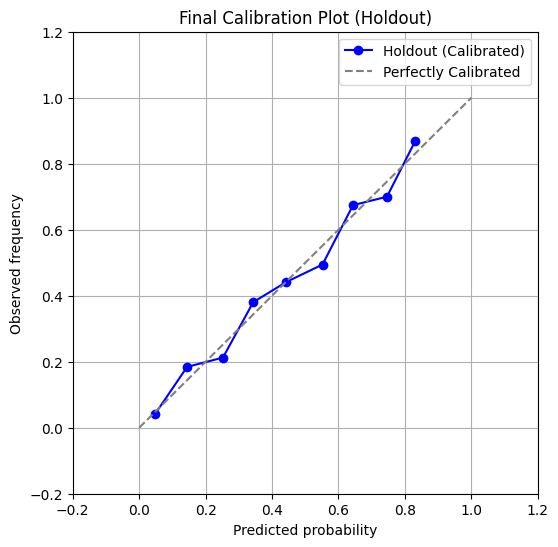

Saved final calibration plot to figures/final_calibration.png


In [ ]:


# --- Load holdout data ---
holdout = pd.read_csv("churn_holdout.csv")

# Extract IDs
holdout_ids = holdout["ID"]

# Separate labels if present
if "Churn" in holdout.columns:
    y_true = holdout["Churn"].map({"Yes": 1, "No": 0}).values
    holdout = holdout.drop("Churn", axis=1)  # drop labels from features
else:
    y_true = None  # labels not available yet

# Restrict to the same final features used in training
final_features = [
    "tenure", "Contract", "PaperlessBilling", "PaymentMethod",   # account
    "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",  # internet
    "MonthlyCharges", "TotalCharges"  # charges
]
X_holdout = holdout[final_features]

# --- Predict churn probabilities with the final calibrated model ---
holdout_probs = calibrated.predict_proba(X_holdout)[:, 1]

# --- Save predictions ---
holdout_df = pd.DataFrame({
    "ID": holdout_ids,
    "score": holdout_probs
})
holdout_df.to_csv("holdout_predictions.csv", index=False)

print("Saved holdout_predictions.csv with shape:", holdout_df.shape)
print(holdout_df.head())

# --- If labels exist, evaluate performance ---
if y_true is not None:
    auc = roc_auc_score(y_true, holdout_probs)
    brier = brier_score_loss(y_true, holdout_probs)

    print(f"Holdout AUC: {auc:.4f}")
    print(f"Holdout Brier score: {brier:.4f}")

    # --- Calibration curve ---
    prob_true, prob_pred = calibration_curve(y_true, holdout_probs, n_bins=10, strategy="uniform")

    plt.figure(figsize=(6,6))
    plt.plot(prob_pred, prob_true, marker="o", label="Holdout (Calibrated)", color="blue")
    plt.plot([0,1],[0,1], linestyle="--", color="gray", label="Perfectly Calibrated")

    plt.xlabel("Predicted probability")
    plt.ylabel("Observed frequency")
    plt.title("Final Calibration Plot (Holdout)")
    plt.legend()
    plt.grid(True)

    # Format axis ticks
    plt.xticks([round(x,2) for x in plt.xticks()[0]])
    plt.yticks([round(y,2) for y in plt.yticks()[0]])

    # Show inline
    plt.show()

    # Save figure
    os.makedirs("figures", exist_ok=True)
    plt.savefig("figures/final_calibration.png", dpi=300, bbox_inches="tight")
    plt.close()

    print("Saved final calibration plot to figures/final_calibration.png")


## Holdout Results

The holdout churn prediction compared to the train dataset gave a strong and consistent performance. Out‑of‑fold validation achieved an AUC of 0.846 and a Brier score of 0.135, while the independent holdout set produced nearly identical results (AUC 0.844, Brier score 0.136). This close alignment confirms that the model generalizes well to unseen customers, with no evidence of overfitting or leakage. In plain terms, the model reliably distinguishes churners from non‑churners and produces well‑calibrated probability estimates. These results provide confidence that the pipeline is both robust and actionable for real‑world decision‑making.

## Calibration comment

The holdout calibration curve Confirms that the probability calibration held up on the holdout set. The predicted outcome and the real outcome aligns with each other strongly.